# Phase 4: Exploratory Data Analysis (EDA)

Comprehensive analysis of the House Pricing dataset after feature engineering.

## Task 1: Import Libraries and Load Data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print('Libraries imported successfully!')

Libraries imported successfully!


In [23]:
# Load feature-engineered data
df = pd.read_csv('train_feature_engineered.csv')

# Load original cleaned data for categorical analysis
df_original = pd.read_csv('train_cleaned.csv')

# Extract target variable
y = df['SalePrice']

print(f'Feature-engineered dataset: {df.shape}')
print(f'Original dataset: {df_original.shape}')
print(f'Target variable: {y.shape}')

Feature-engineered dataset: (1458, 105)
Original dataset: (1458, 77)
Target variable: (1458,)


## Task 2: Target Variable Analysis

### Step 2.1: Statistical Summary of Target Variable

In [24]:
q1, q2, q3 = y.quantile([0.25, 0.50, 0.75])
skewness  = stats.skew(y)
kurt      = stats.kurtosis(y)

print('=' * 50)
print('SALEPRICE - STATISTICAL SUMMARY')
print('=' * 50)
print(f'  Count    : {len(y):,}')
print(f'  Mean     : ${y.mean():,.2f}')
print(f'  Median   : ${y.median():,.2f}')
print(f'  Std Dev  : ${y.std():,.2f}')
print(f'  Min      : ${y.min():,.2f}')
print(f'  Max      : ${y.max():,.2f}')
print(f'  Range    : ${y.max() - y.min():,.2f}')
print(f'  Q1 (25%) : ${q1:,.2f}')
print(f'  Q2 (50%) : ${q2:,.2f}')
print(f'  Q3 (75%) : ${q3:,.2f}')
print(f'  IQR      : ${q3 - q1:,.2f}')
print(f'  Skewness : {skewness:.4f}')
print(f'  Kurtosis : {kurt:.4f}')

SALEPRICE - STATISTICAL SUMMARY
  Count    : 1,458
  Mean     : $180,932.92
  Median   : $163,000.00
  Std Dev  : $79,495.06
  Min      : $34,900.00
  Max      : $755,000.00
  Range    : $720,100.00
  Q1 (25%) : $129,925.00
  Q2 (50%) : $163,000.00
  Q3 (75%) : $214,000.00
  IQR      : $84,075.00
  Skewness : 1.8794
  Kurtosis : 6.4966


### Step 2.2: Visualize Target Distribution

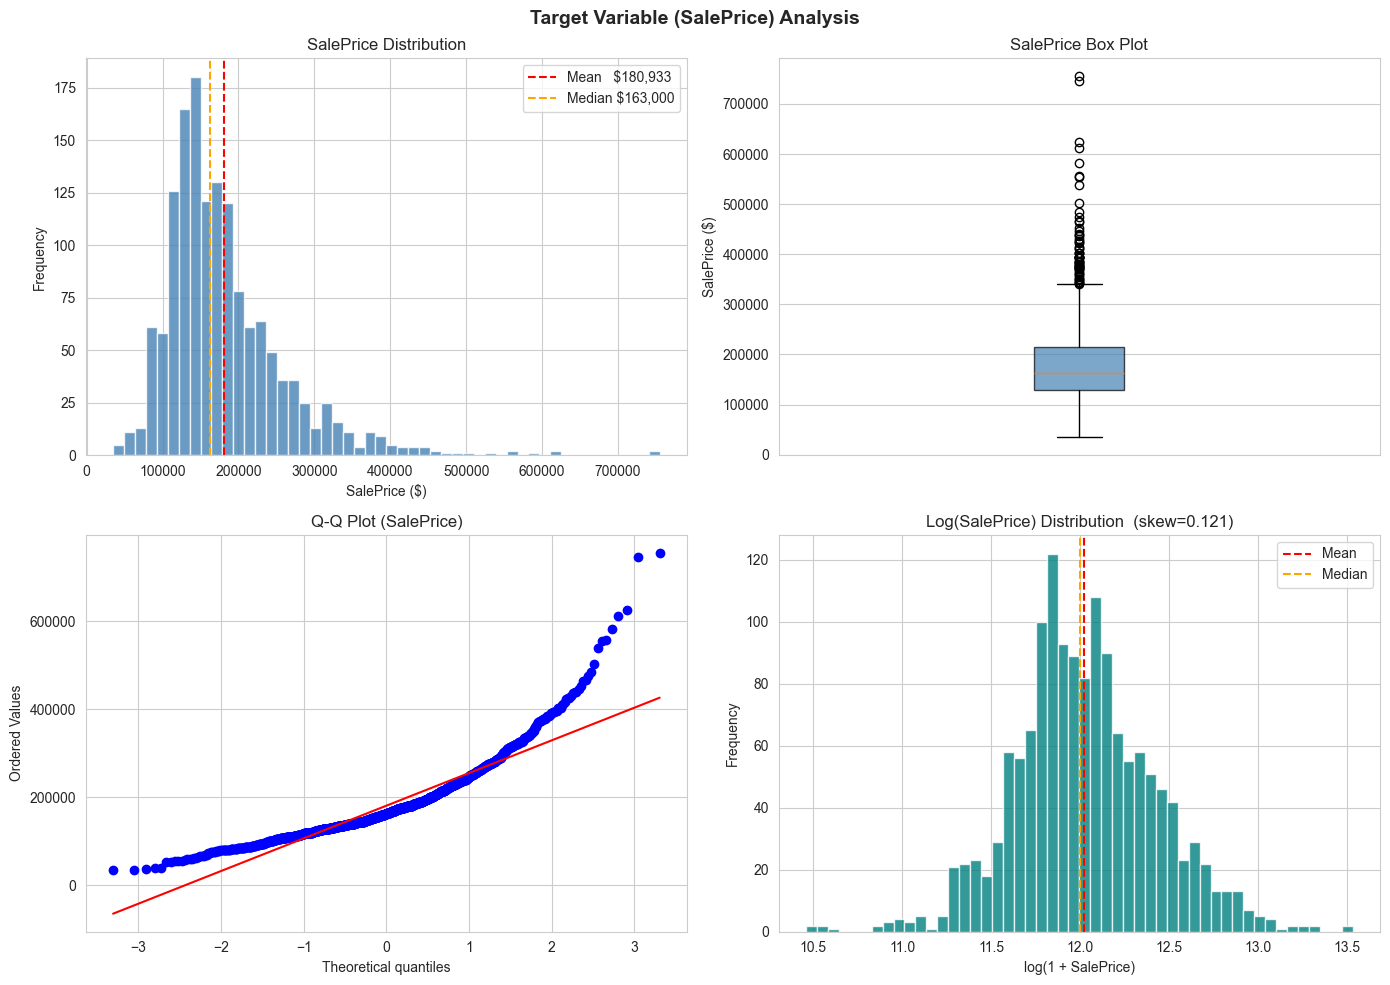

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram with mean/median lines
axes[0, 0].hist(y, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(y.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean   ${y.mean():,.0f}')
axes[0, 0].axvline(y.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median ${y.median():,.0f}')
axes[0, 0].set_title('SalePrice Distribution')
axes[0, 0].set_xlabel('SalePrice ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# 2. Box plot
axes[0, 1].boxplot(y, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0, 1].set_title('SalePrice Box Plot')
axes[0, 1].set_ylabel('SalePrice ($)')
axes[0, 1].set_xticks([])

# 3. Q-Q plot
stats.probplot(y, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (SalePrice)')

# 4. Log-transformed histogram
log_y = np.log1p(y)
axes[1, 1].hist(log_y, bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(log_y.mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
axes[1, 1].axvline(log_y.median(), color='orange', linestyle='--', linewidth=1.5, label='Median')
axes[1, 1].set_title(f'Log(SalePrice) Distribution  (skew={stats.skew(log_y):.3f})')
axes[1, 1].set_xlabel('log(1 + SalePrice)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.suptitle('Target Variable (SalePrice) Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- The SalePrice distribution is **right-skewed** — most houses cluster in the lower-to-mid range with a long tail of high-value properties
- The Q-Q plot confirms departure from normality at both tails
- Log transformation significantly reduces skewness and brings the distribution closer to normal, which is why log(SalePrice) is used as the modeling target

## Task 3: Univariate Analysis - Numerical Features

In [26]:
numerical_features = [
    c for c in df_original.select_dtypes(include=['int64', 'float64']).columns
    if c not in ('Id', 'SalePrice')
]
print(f'Numerical features to analyze: {len(numerical_features)}')

Numerical features to analyze: 36


### Step 3.1: Distribution Analysis of Key Numerical Features

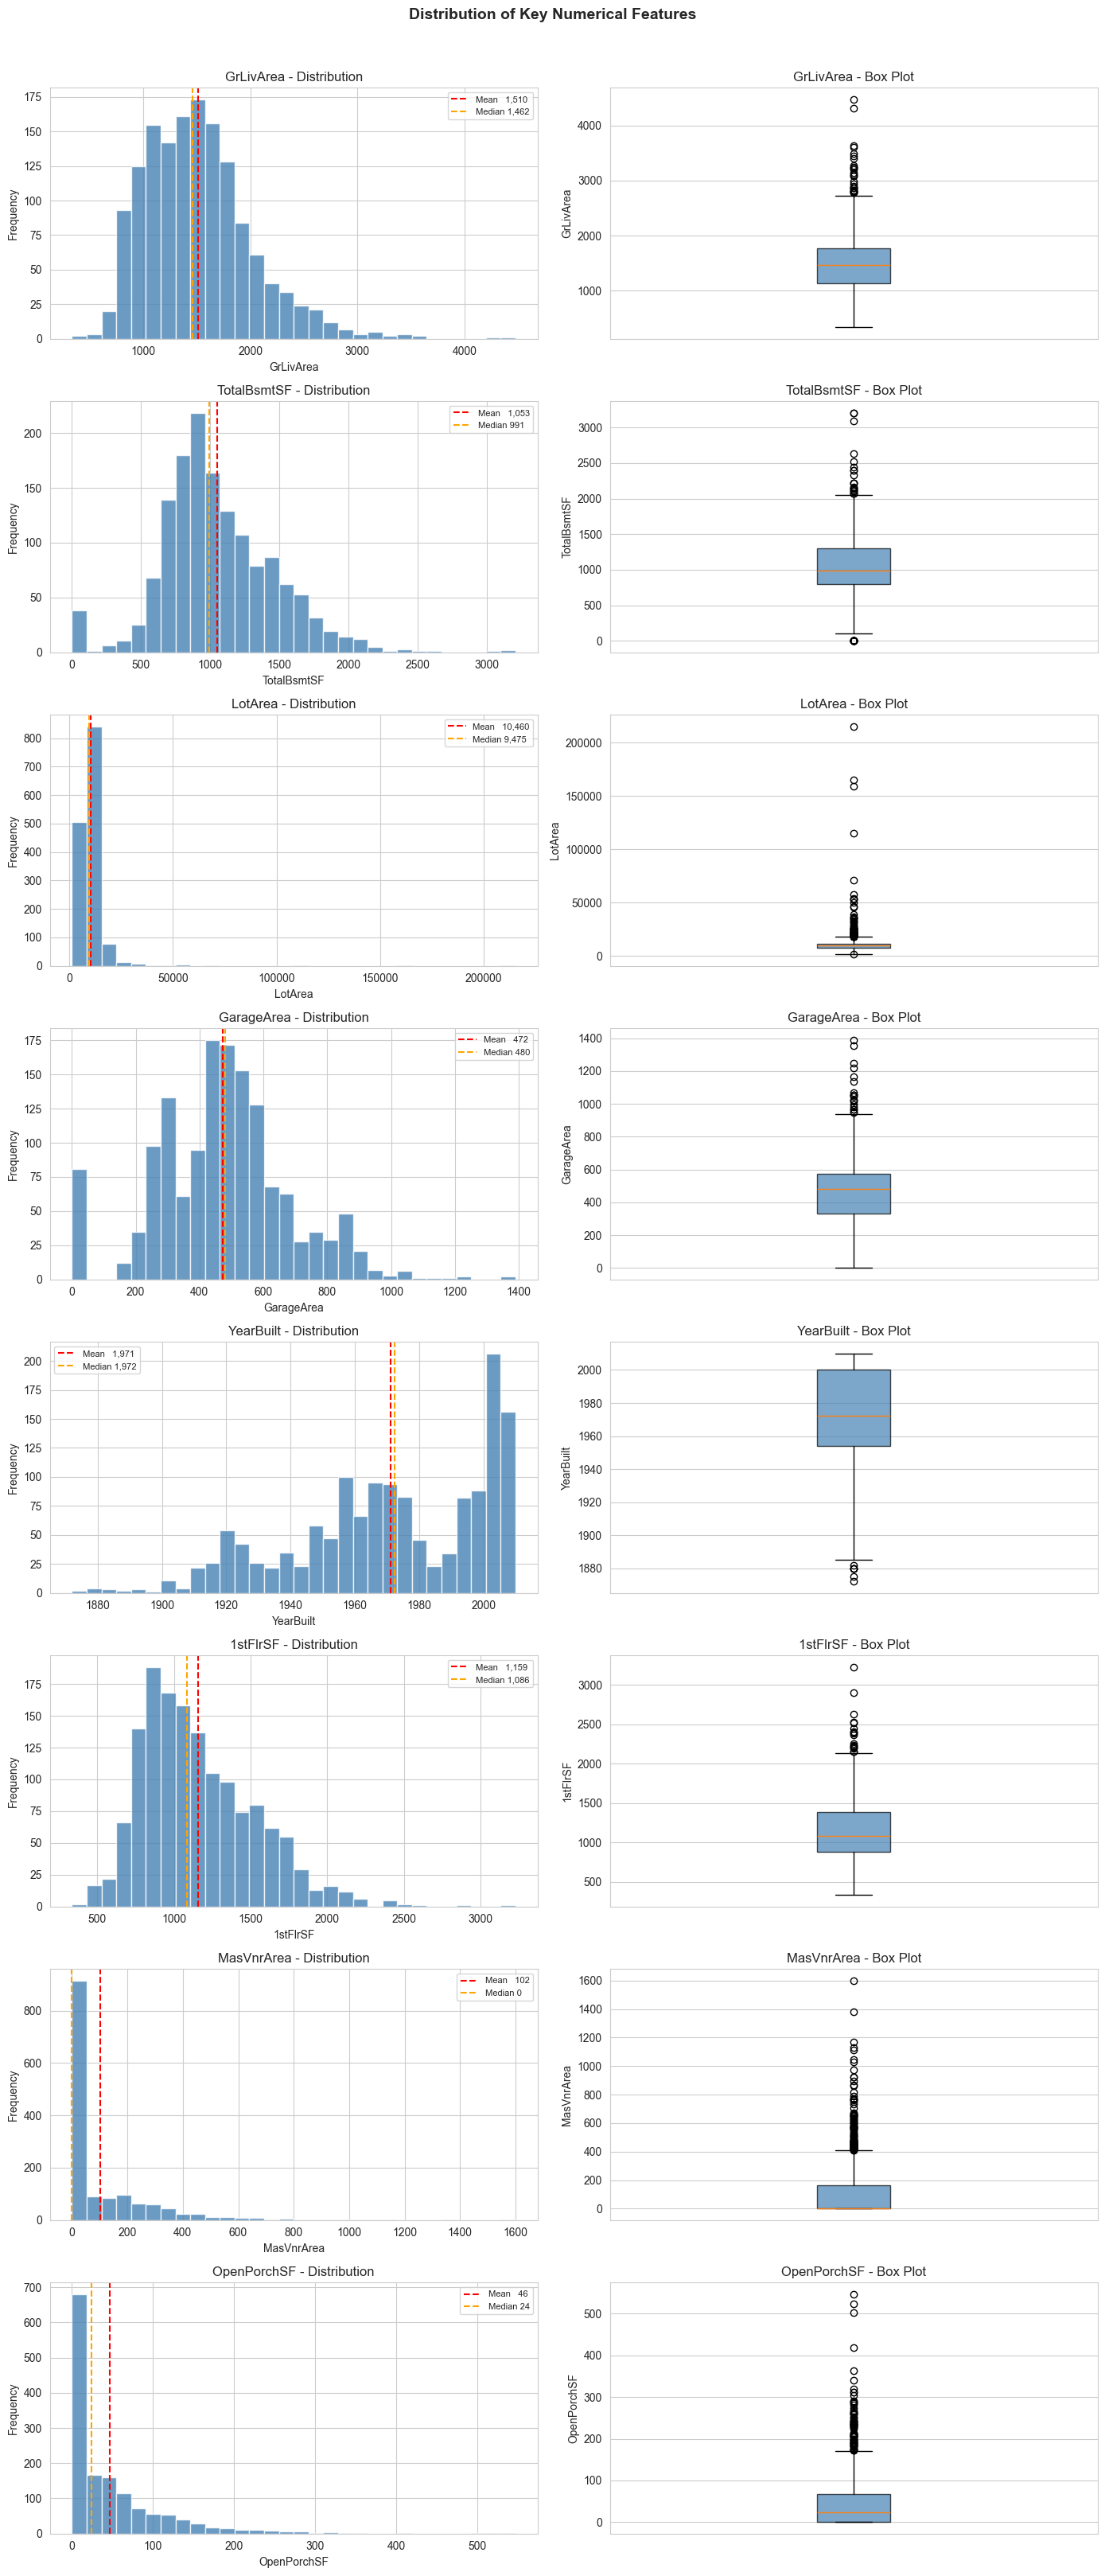

In [27]:
key_features_candidates = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'GarageArea', 'YearBuilt',
                            '1stFlrSF', 'MasVnrArea', 'OpenPorchSF']
key_features = [f for f in key_features_candidates if f in df_original.columns]

fig, axes = plt.subplots(len(key_features), 2, figsize=(14, 4 * len(key_features)))

for i, feat in enumerate(key_features):
    data = df_original[feat].dropna()

    # Histogram
    axes[i, 0].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean   {data.mean():,.0f}')
    axes[i, 0].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median {data.median():,.0f}')
    axes[i, 0].set_title(f'{feat} - Distribution')
    axes[i, 0].set_xlabel(feat)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].legend(fontsize=8)

    # Boxplot
    axes[i, 1].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i, 1].set_title(f'{feat} - Box Plot')
    axes[i, 1].set_ylabel(feat)
    axes[i, 1].set_xticks([])

plt.suptitle('Distribution of Key Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Task 4: Univariate Analysis - Categorical Features

In [28]:
categorical_features = df_original.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
print(f'Categorical features: {len(categorical_features)}')
print()
print(f'{"Feature":<20} Unique Values')
print('-' * 35)
for feat in categorical_features:
    print(f'{feat:<20} {df_original[feat].nunique()}')


Categorical features: 39

Feature              Unique Values
-----------------------------------
MSZoning             5
Street               2
LotShape             4
LandContour          4
Utilities            2
LotConfig            5
LandSlope            3
Neighborhood         25
Condition1           9
Condition2           8
BldgType             5
HouseStyle           8
RoofStyle            6
RoofMatl             7
Exterior1st          15
Exterior2nd          16
MasVnrType           3
ExterQual            4
ExterCond            5
Foundation           6
BsmtQual             4
BsmtCond             4
BsmtExposure         4
BsmtFinType1         6
BsmtFinType2         6
Heating              6
HeatingQC            5
CentralAir           2
Electrical           5
KitchenQual          4
Functional           7
FireplaceQu          5
GarageType           6
GarageFinish         3
GarageQual           5
GarageCond           5
PavedDrive           3
SaleType             9
SaleCondition        6


### Step 4.1: Visualize Key Categorical Features

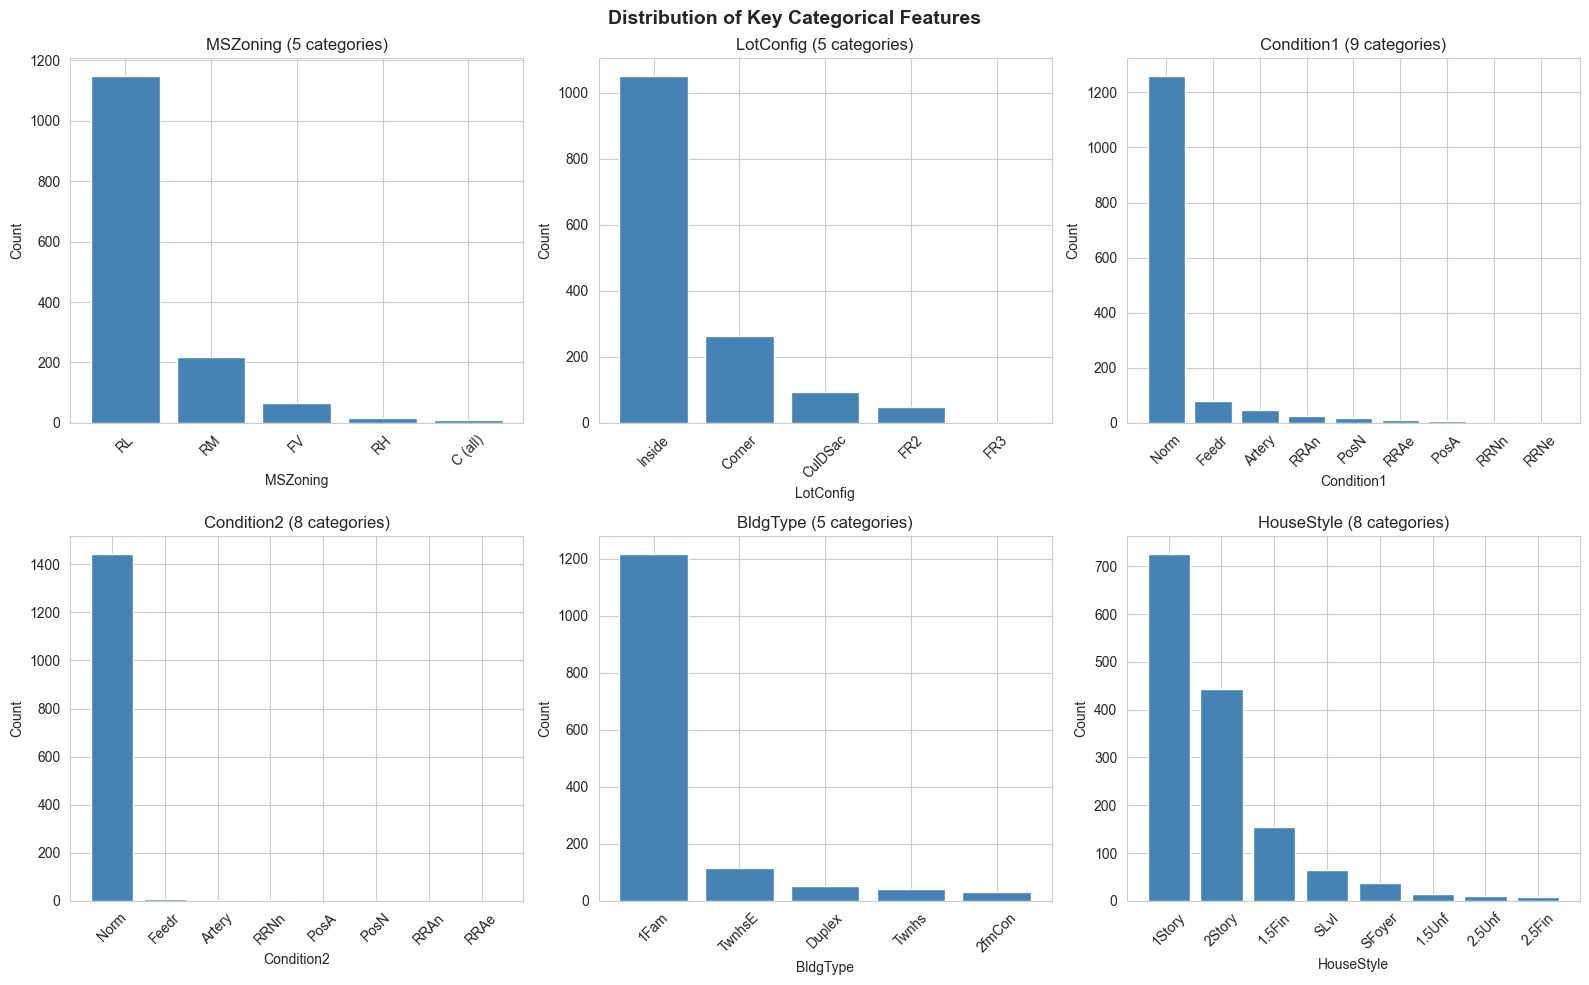

In [29]:
# Select features with moderate cardinality (5-15 unique values)
cat_moderate = [
    f for f in categorical_features
    if 5 <= df_original[f].nunique() <= 15
][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_moderate):
    counts = df_original[feat].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{feat} ({len(counts)} categories)')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(len(cat_moderate), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 5: Bivariate Analysis - Numerical vs Target

### Step 5.1: Correlation Analysis

Top 15 features most correlated with SalePrice:
SalePrice              1.000000
Quality_x_TotalSF      0.918990
Quality_x_Area         0.874116
TotalSF                0.832877
OverallQual_Squared    0.824582
OverallQual            0.795774
GrLivArea              0.734968
GrLivArea_Squared      0.730811
TotalBsmtSF            0.651153
GarageCars             0.641047
TotalBathrooms         0.635896
1stFlrSF               0.631530
GarageArea             0.629217
QualCondScore          0.596672
Qual_x_Cond            0.566759
FullBath               0.562165


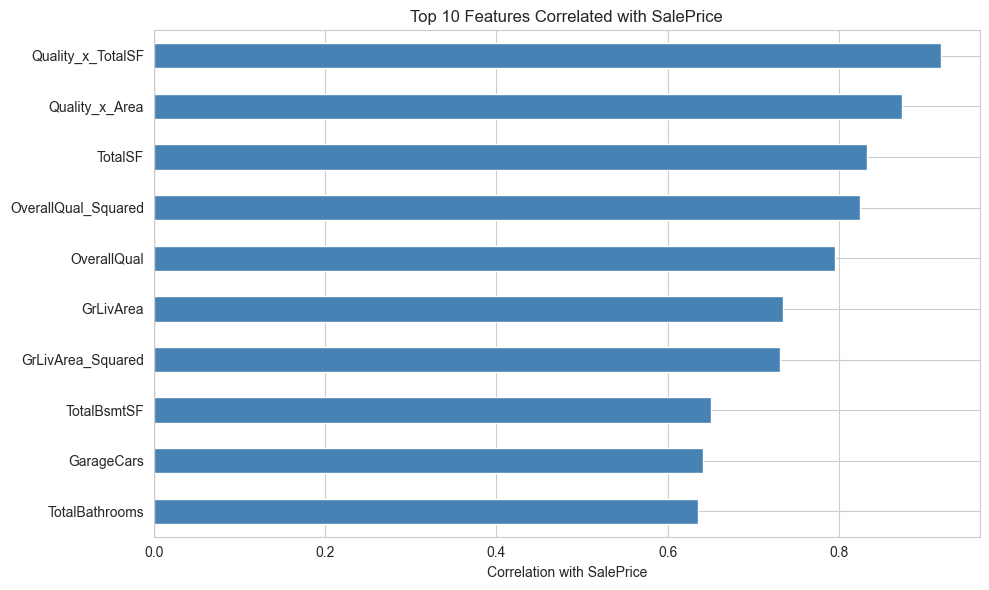

In [30]:
# Correlations using feature-engineered dataset
correlations = (
    df.select_dtypes(include=[np.number])
      .corr()['SalePrice']
      .sort_values(ascending=False)
)

print('Top 15 features most correlated with SalePrice:')
print(correlations.head(16).to_string())

# Horizontal bar chart of top 10 (excluding SalePrice itself)
top10 = correlations.drop('SalePrice').head(10)

plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Correlation with SalePrice')
plt.title('Top 10 Features Correlated with SalePrice')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### Step 5.2: Scatter Plots of Top Features vs SalePrice

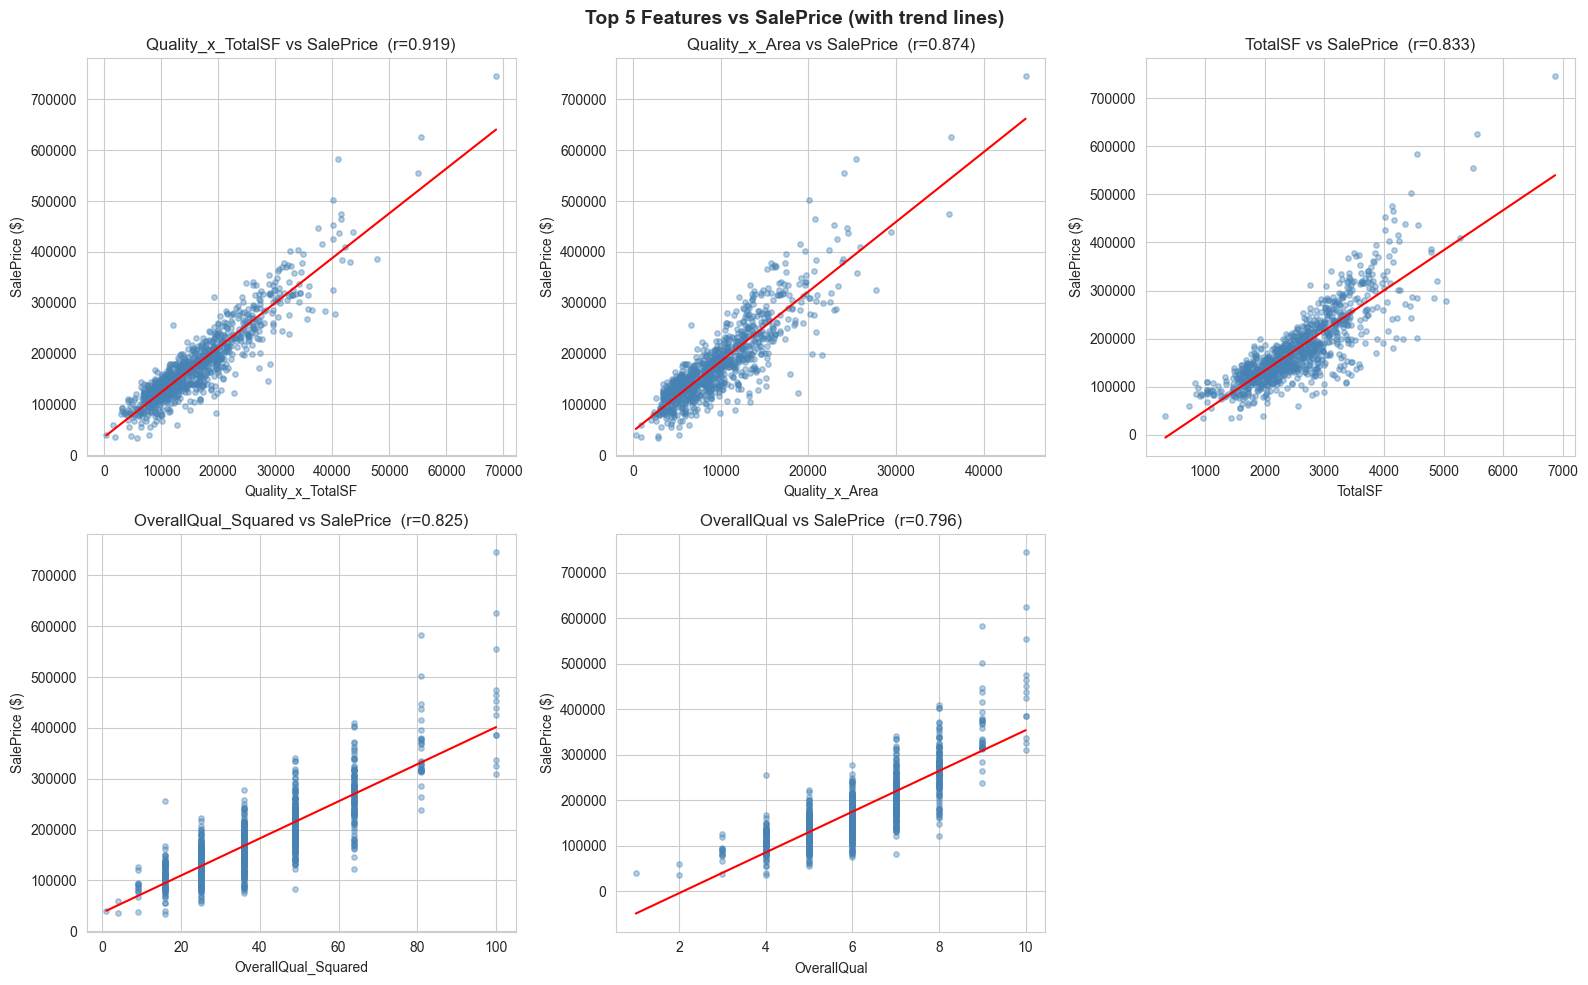

In [31]:
top5 = correlations.drop('SalePrice').head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Sample for performance if dataset is large
plot_df = df.sample(n=min(1000, len(df)), random_state=42)

for i, feat in enumerate(top5):
    if feat not in plot_df.columns:
        continue
    x_data = plot_df[feat].dropna()
    y_data = plot_df.loc[x_data.index, 'SalePrice']

    axes[i].scatter(x_data, y_data, alpha=0.4, s=15, color='steelblue')

    # Trend line
    z = np.polyfit(x_data, y_data, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x_data.min(), x_data.max(), 200)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1.5)

    r = correlations[feat]
    axes[i].set_title(f'{feat} vs SalePrice  (r={r:.3f})')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice ($)')

# Hide unused subplot
for j in range(len(top5), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 5 Features vs SalePrice (with trend lines)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 6: Bivariate Analysis - Categorical vs Target

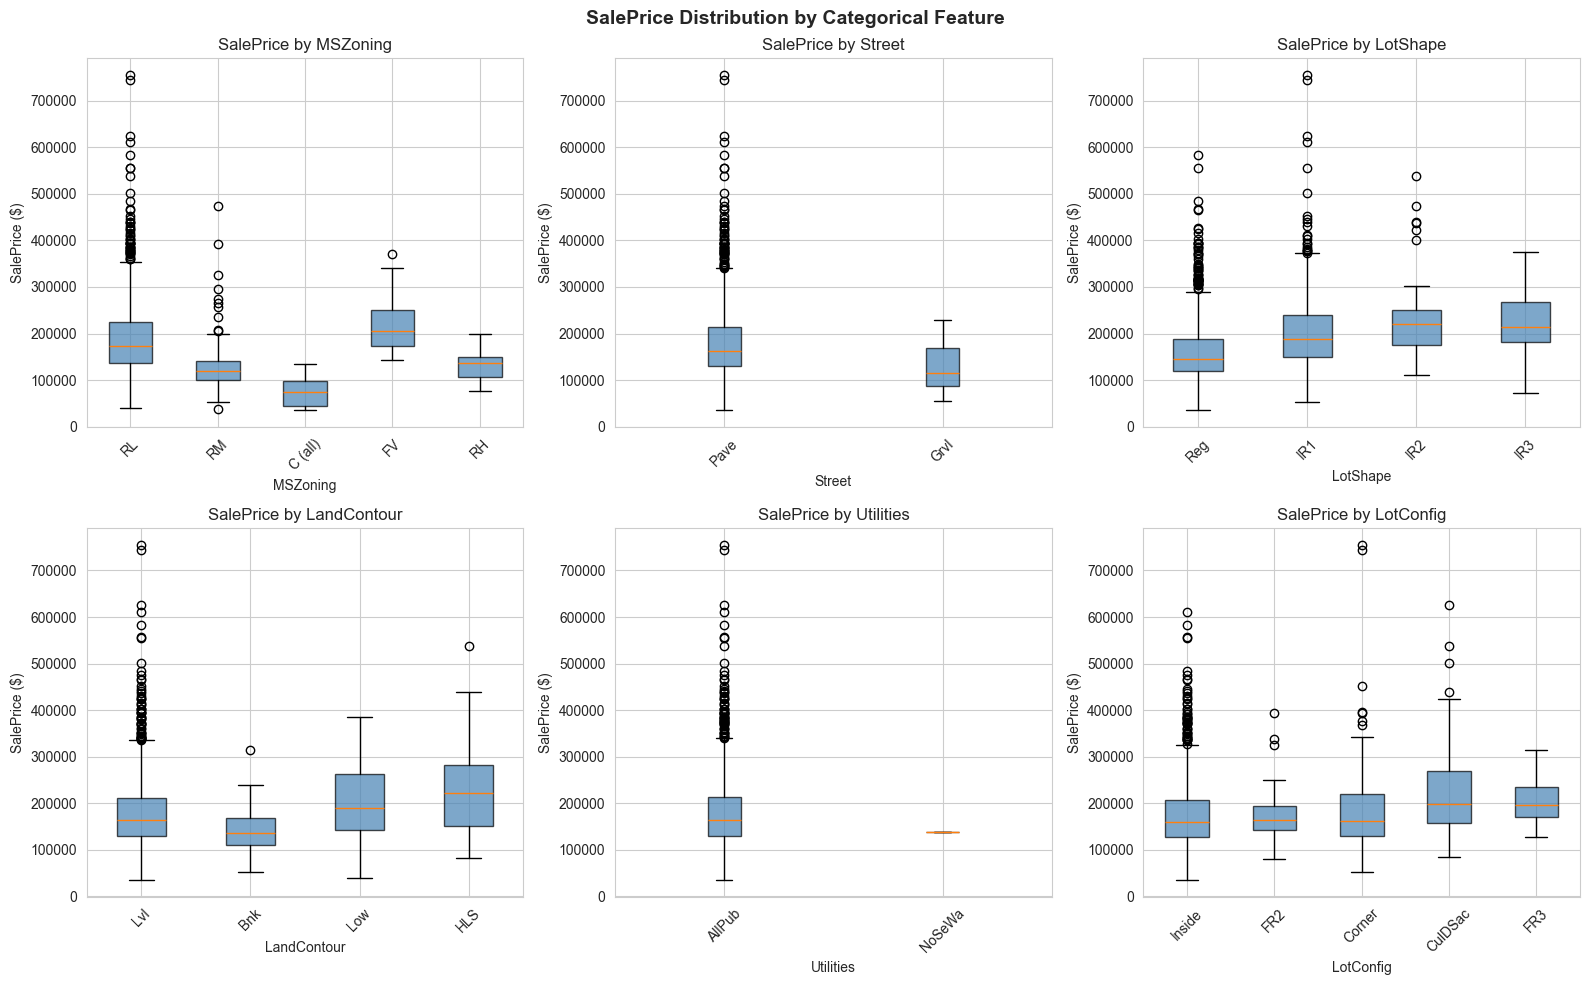

In [32]:
# Categorical features with 2-10 unique values
cat_bivariate = [
    f for f in categorical_features
    if 2 <= df_original[f].nunique() <= 10
][:6]

# Merge target onto original for plotting
df_plot = df_original.copy()
df_plot['SalePrice'] = y.values

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_bivariate):
    data = [df_plot.loc[df_plot[feat] == cat, 'SalePrice'].values
            for cat in df_plot[feat].dropna().unique()]
    labels = df_plot[feat].dropna().unique()

    axes[i].boxplot(data, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(f'SalePrice by {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice ($)')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_bivariate), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('SalePrice Distribution by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 6.1: Statistical Analysis by Category

In [33]:
top3_cat = cat_bivariate[:3]

for feat in top3_cat:
    stats_table = (
        df_plot.groupby(feat)['SalePrice']
               .agg(Count='count', Mean='mean', Median='median', Std='std')
               .sort_values('Mean', ascending=False)
    )
    print(f'\nSalePrice statistics by {feat}:')
    print(stats_table.to_string())


SalePrice statistics by MSZoning:
          Count           Mean    Median           Std
MSZoning                                              
FV           65  214014.061538  205950.0  52369.662067
RL         1149  191037.422977  174000.0  80831.267725
RH           16  131558.375000  136500.0  35714.118435
RM          218  126316.830275  120500.0  48521.689833
C (all)      10   74528.000000   74700.0  33791.092031

SalePrice statistics by Street:
        Count           Mean    Median           Std
Street                                              
Pave     1452  181142.598485  163000.0  79499.338432
Grvl        6  130190.500000  114250.0  65446.253991

SalePrice statistics by LotShape:
          Count           Mean    Median           Std
LotShape                                              
IR2          41  239833.365854  221000.0  99669.427362
IR3           9  222262.777778  215000.0  85019.978355
IR1         483  206145.871636  189000.0  85941.994252
Reg         925  164754.8

## Task 7: Multivariate Analysis

### Step 7.1: Correlation Heatmap

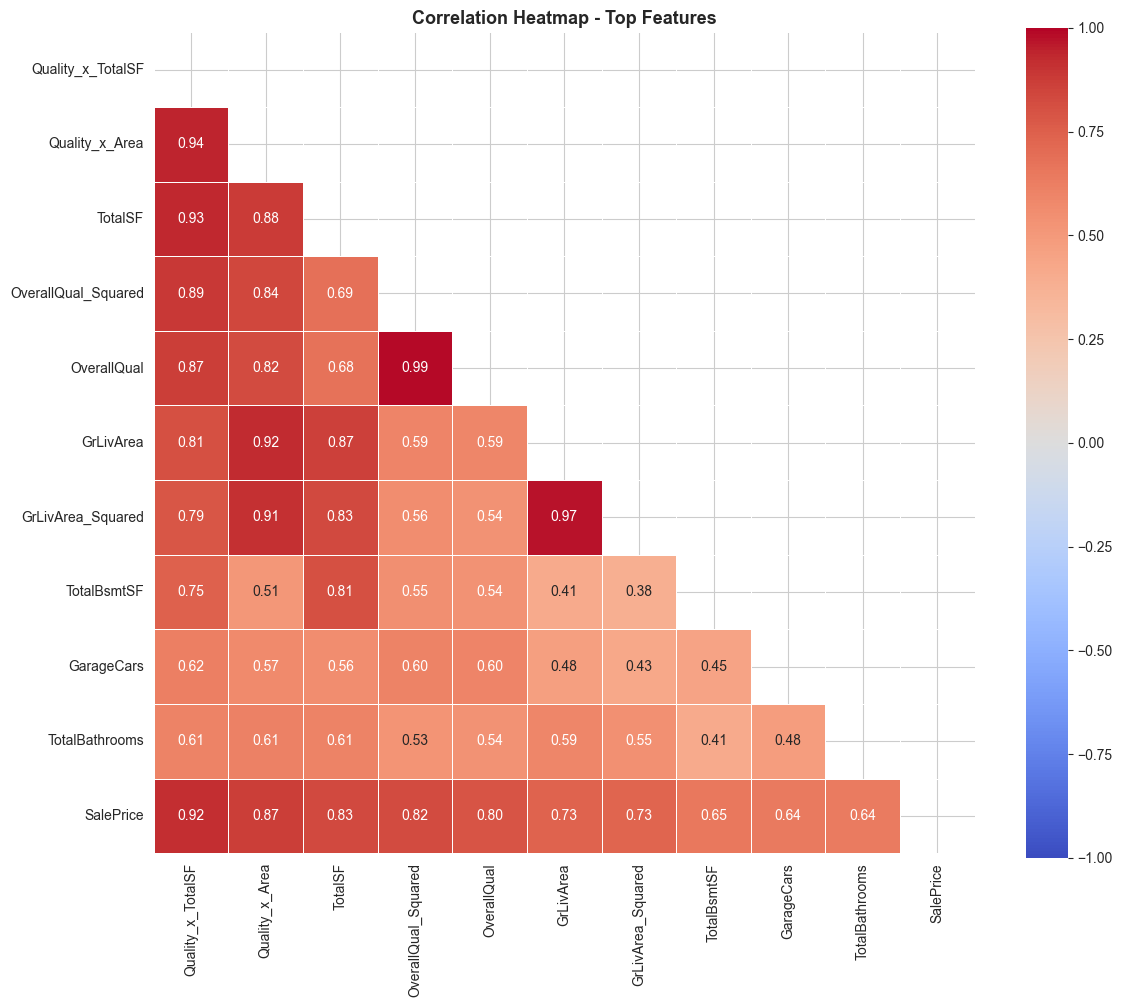

In [34]:
top11 = correlations.drop('SalePrice').head(10).index.tolist() + ['SalePrice']
corr_matrix = df[top11].corr()

plt.figure(figsize=(12, 10))
# Diagonal + yuxarı üçbucağı maskla - hər cüt yalnız bir dəfə görünsün
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap - Top Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 7.2: Pair Plot of Key Features

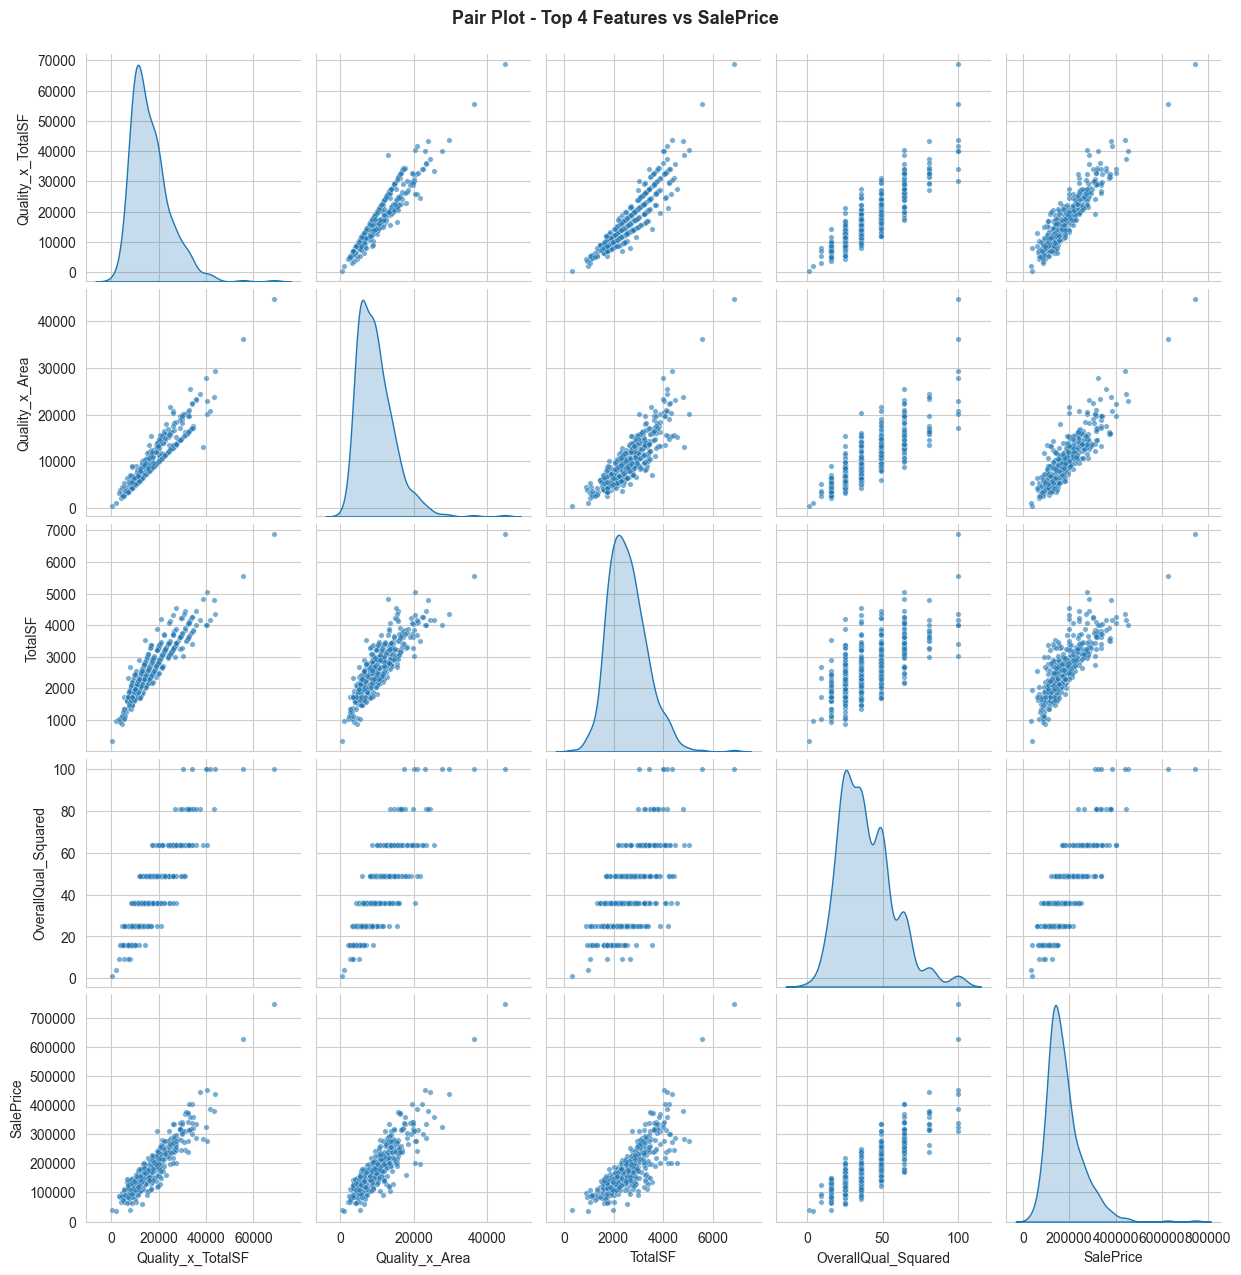

In [35]:
top4 = correlations.drop('SalePrice').head(4).index.tolist()
pair_df = df[top4 + ['SalePrice']].dropna()

# pairplot böyük datasette yavaşdır - sample götür
pair_sample = pair_df.sample(n=min(500, len(pair_df)), random_state=42)

pair_grid = sns.pairplot(pair_sample, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 15})
pair_grid.figure.suptitle('Pair Plot - Top 4 Features vs SalePrice', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## Task 8: Analyze Engineered Features

In [36]:
# Load list of new features
try:
    with open('new_features_list.txt') as f:
        print(f.read())
except FileNotFoundError:
    print('new_features_list.txt not found - run Phase 3 notebook first.')

New Features Created:
----------------------------------------
 1. TotalSF
 2. TotalBathrooms
 3. TotalPorchSF
 4. TotalOutdoorSF
 5. TotalBsmtFinSF
 6. QualCondScore
 7. LivingArea_to_LotArea
 8. BasementRatio
 9. GarageArea_to_LivArea
10. Bedroom_to_TotalRooms
11. HouseAge
12. YearsSinceRemodel
13. GarageAge
14. IsNewHouse
15. HasSecondFloor
16. HasBasement
17. HasGarage
18. HasFireplace
19. HasPool
20. HasPorch
21. HasDeck
22. IsRemodeled
23. Quality_x_Area
24. Qual_x_Cond
25. Quality_x_TotalSF
26. Bathrooms_x_Bedrooms
27. OverallQual_Squared
28. GrLivArea_Squared



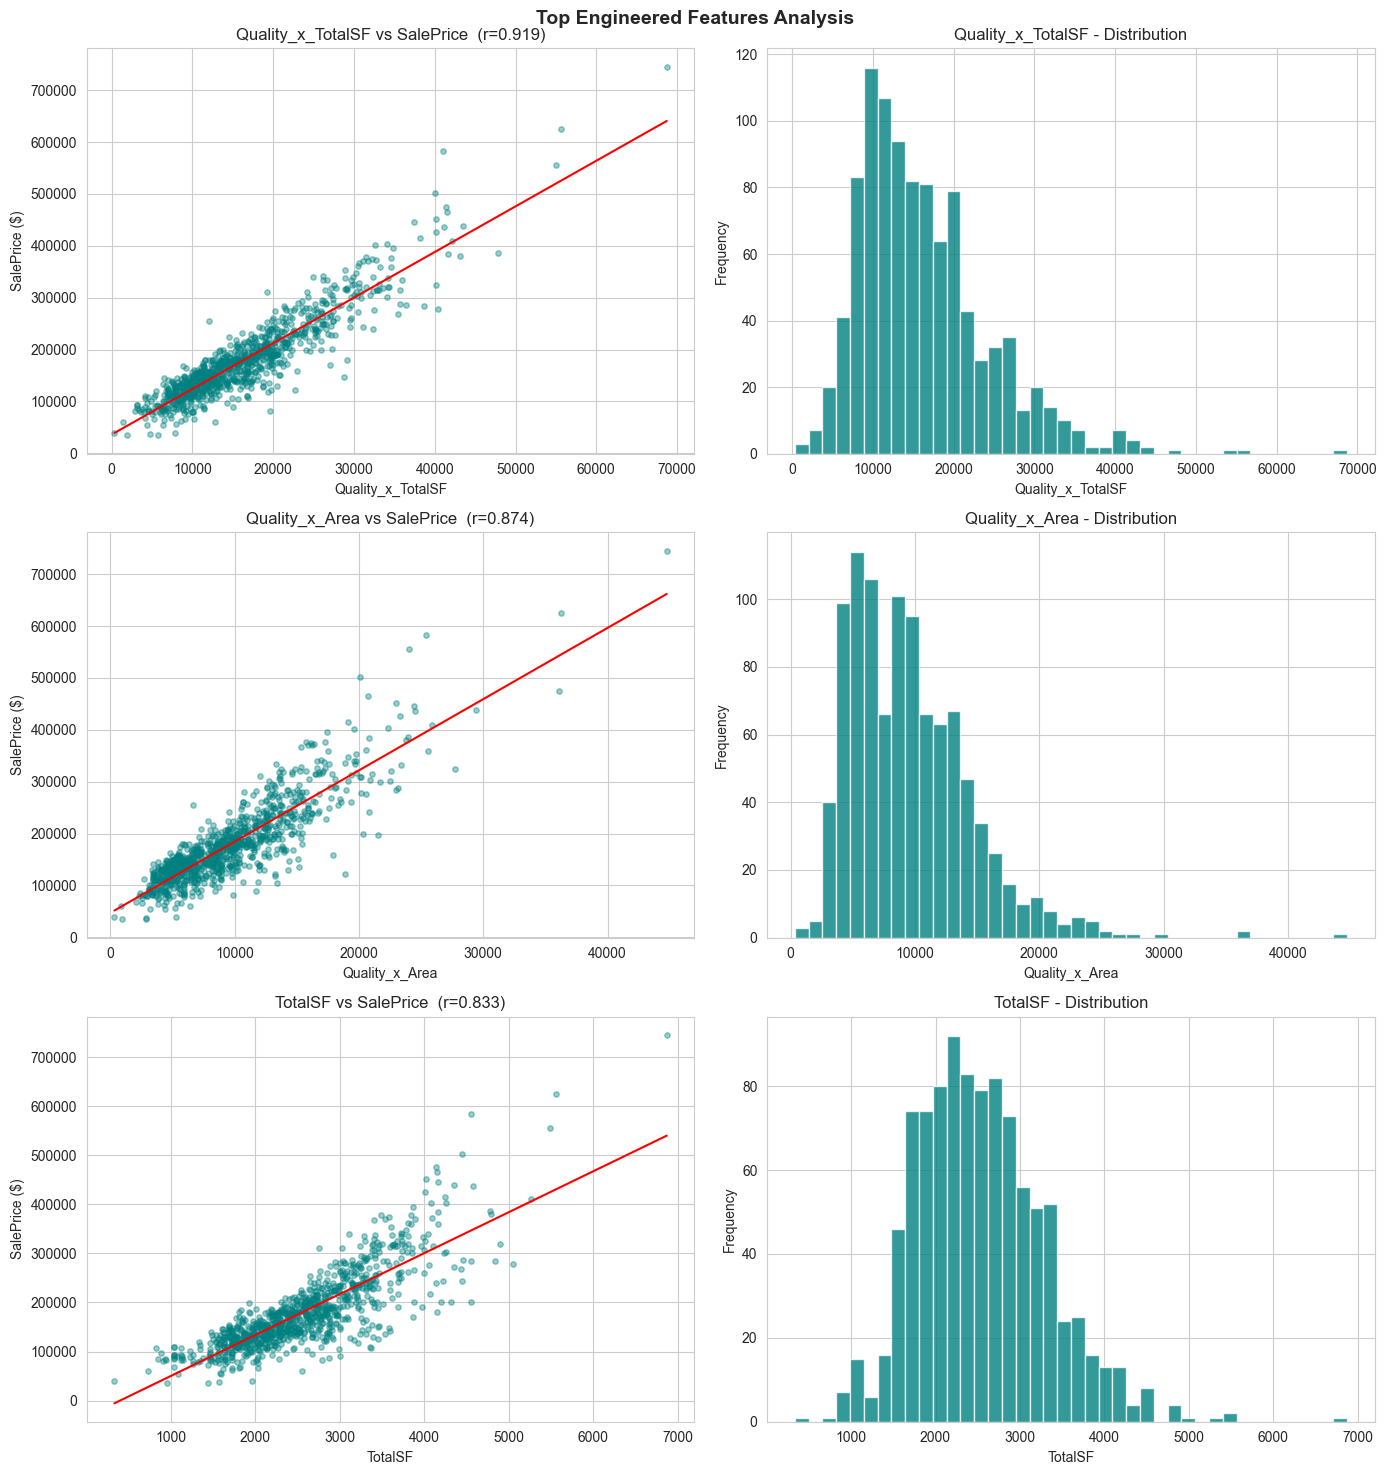

In [37]:
# Identify engineered features present in df
original_cols = set(df_original.columns)
engineered_features = [c for c in df.columns if c not in original_cols and c != 'SalePrice']

# Get their correlations
eng_corrs = correlations[engineered_features].sort_values(ascending=False)

# Focus on top 3 engineered features
top3_eng = eng_corrs.head(3).index.tolist()

fig, axes = plt.subplots(len(top3_eng), 2, figsize=(14, 5 * len(top3_eng)))
if len(top3_eng) == 1:
    axes = [axes]

# Sample for performance
eng_plot_df = df.sample(n=min(1000, len(df)), random_state=42)

for i, feat in enumerate(top3_eng):
    data = eng_plot_df[feat].dropna()
    sp   = eng_plot_df.loc[data.index, 'SalePrice']

    # Scatter vs SalePrice
    axes[i][0].scatter(data, sp, alpha=0.4, s=15, color='teal')
    z = np.polyfit(data, sp, 1)
    x_line = np.linspace(data.min(), data.max(), 200)
    axes[i][0].plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=1.5)
    axes[i][0].set_title(f'{feat} vs SalePrice  (r={eng_corrs[feat]:.3f})')
    axes[i][0].set_xlabel(feat)
    axes[i][0].set_ylabel('SalePrice ($)')

    # Distribution
    axes[i][1].hist(data, bins=40, color='teal', edgecolor='white', alpha=0.8)
    axes[i][1].set_title(f'{feat} - Distribution')
    axes[i][1].set_xlabel(feat)
    axes[i][1].set_ylabel('Frequency')

plt.suptitle('Top Engineered Features Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 9: Key Insights and Patterns

### Step 9.1: Document Your Findings

### Step 9.2: Skewness Summary of Numerical Features

Highly skewed features (|skew| > 1.0):
      Feature  Skewness
      MiscVal 24.434913
     PoolArea 15.932532
      LotArea 12.560986
    3SsnPorch 10.286510
 LowQualFinSF  8.995688
 KitchenAbvGr  4.480268
   BsmtFinSF2  4.247550
  ScreenPorch  4.114690
 BsmtHalfBath  4.095895
  GarageYrBlt -3.862401
EnclosedPorch  3.083987
   MasVnrArea  2.693554
  OpenPorchSF  2.337421
  LotFrontage  1.546174
   WoodDeckSF  1.544214
   MSSubClass  1.405563
    GrLivArea  1.009951


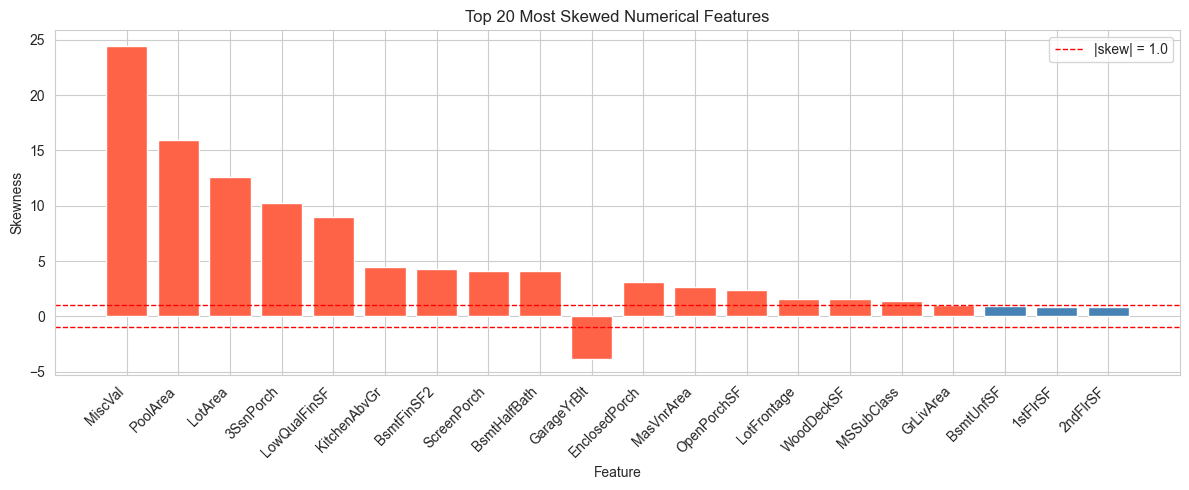

In [38]:
# Skewness cədvəli - hansı featurelar log transform tələb edir
num_cols = df_original.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ('Id', 'SalePrice')]

skew_df = (
    pd.DataFrame({
        'Feature': num_cols,
        'Skewness': [stats.skew(df_original[c].dropna()) for c in num_cols]
    })
    .assign(AbsSkew=lambda d: d['Skewness'].abs())
    .sort_values('AbsSkew', ascending=False)
    .reset_index(drop=True)
)

print('Highly skewed features (|skew| > 1.0):')
print(skew_df[skew_df['AbsSkew'] > 1.0][['Feature', 'Skewness']].to_string(index=False))

# Görselleştirmə
plt.figure(figsize=(12, 5))
top_skew = skew_df.head(20)
colors = ['tomato' if abs(v) > 1.0 else 'steelblue' for v in top_skew['Skewness']]
plt.bar(top_skew['Feature'], top_skew['Skewness'], color=colors, edgecolor='white')
plt.axhline(y=1.0,  color='red', linestyle='--', linewidth=1, label='|skew| = 1.0')
plt.axhline(y=-1.0, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Skewness')
plt.title('Top 20 Most Skewed Numerical Features')
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
num_features   = df_original.select_dtypes(include=[np.number]).shape[1]
cat_feat_count = len(categorical_features)
top5_corr      = correlations.drop('SalePrice').head(5)

print('=' * 60)
print('EDA SUMMARY REPORT')
print('=' * 60)

print('\n1. DATASET OVERVIEW')
print(f'   Total samples          : {len(df):,}')
print(f'   Total features (eng.)  : {df.shape[1] - 1}  (excl. SalePrice)')
print(f'   Numerical features     : {num_features}')
print(f'   Categorical features   : {cat_feat_count}')
print(f'   Engineered features    : {len(engineered_features)}')

print('\n2. TARGET VARIABLE (SalePrice)')
print(f'   Mean     : ${y.mean():,.0f}')
print(f'   Median   : ${y.median():,.0f}')
print(f'   Range    : ${y.min():,.0f} - ${y.max():,.0f}')
print(f'   Skewness : {stats.skew(y):.4f}  (right-skewed, log transform recommended)')

print('\n3. TOP 5 MOST CORRELATED FEATURES')
for feat, val in top5_corr.items():
    print(f'   {feat:<30} r = {val:.4f}')

print('\n4. KEY OBSERVATIONS')
print('   - Overall quality (OverallQual) is the single strongest predictor')
print('   - Size-related features (TotalSF, GrLivArea, Quality_x_Area) are top predictors')
print('   - Engineered interaction features outperform their individual components')
print('   - House age and remodel status significantly affect pricing')
print('   - Several size features are highly correlated (multicollinearity risk)')

print('\n5. RECOMMENDATIONS FOR MODELING')
print('   - Use log(SalePrice) as the target to correct right skew')
print('   - Apply log/sqrt transforms to right-skewed features (LotArea, etc.)')
print('   - Consider dropping one feature from each high-correlation pair')
print('   - Tree-based models (XGBoost, Random Forest) will handle non-linearities well')
print('   - Engineered interaction features should be kept - strong signal')
print('=' * 60)

EDA SUMMARY REPORT

1. DATASET OVERVIEW
   Total samples          : 1,458
   Total features (eng.)  : 104  (excl. SalePrice)
   Numerical features     : 38
   Categorical features   : 39
   Engineered features    : 28

2. TARGET VARIABLE (SalePrice)
   Mean     : $180,933
   Median   : $163,000
   Range    : $34,900 - $755,000
   Skewness : 1.8794  (right-skewed, log transform recommended)

3. TOP 5 MOST CORRELATED FEATURES
   Quality_x_TotalSF              r = 0.9190
   Quality_x_Area                 r = 0.8741
   TotalSF                        r = 0.8329
   OverallQual_Squared            r = 0.8246
   OverallQual                    r = 0.7958

4. KEY OBSERVATIONS
   - Overall quality (OverallQual) is the single strongest predictor
   - Size-related features (TotalSF, GrLivArea, Quality_x_Area) are top predictors
   - Engineered interaction features outperform their individual components
   - House age and remodel status significantly affect pricing
   - Several size features are high

## Task 10: Final Dashboard Visualization

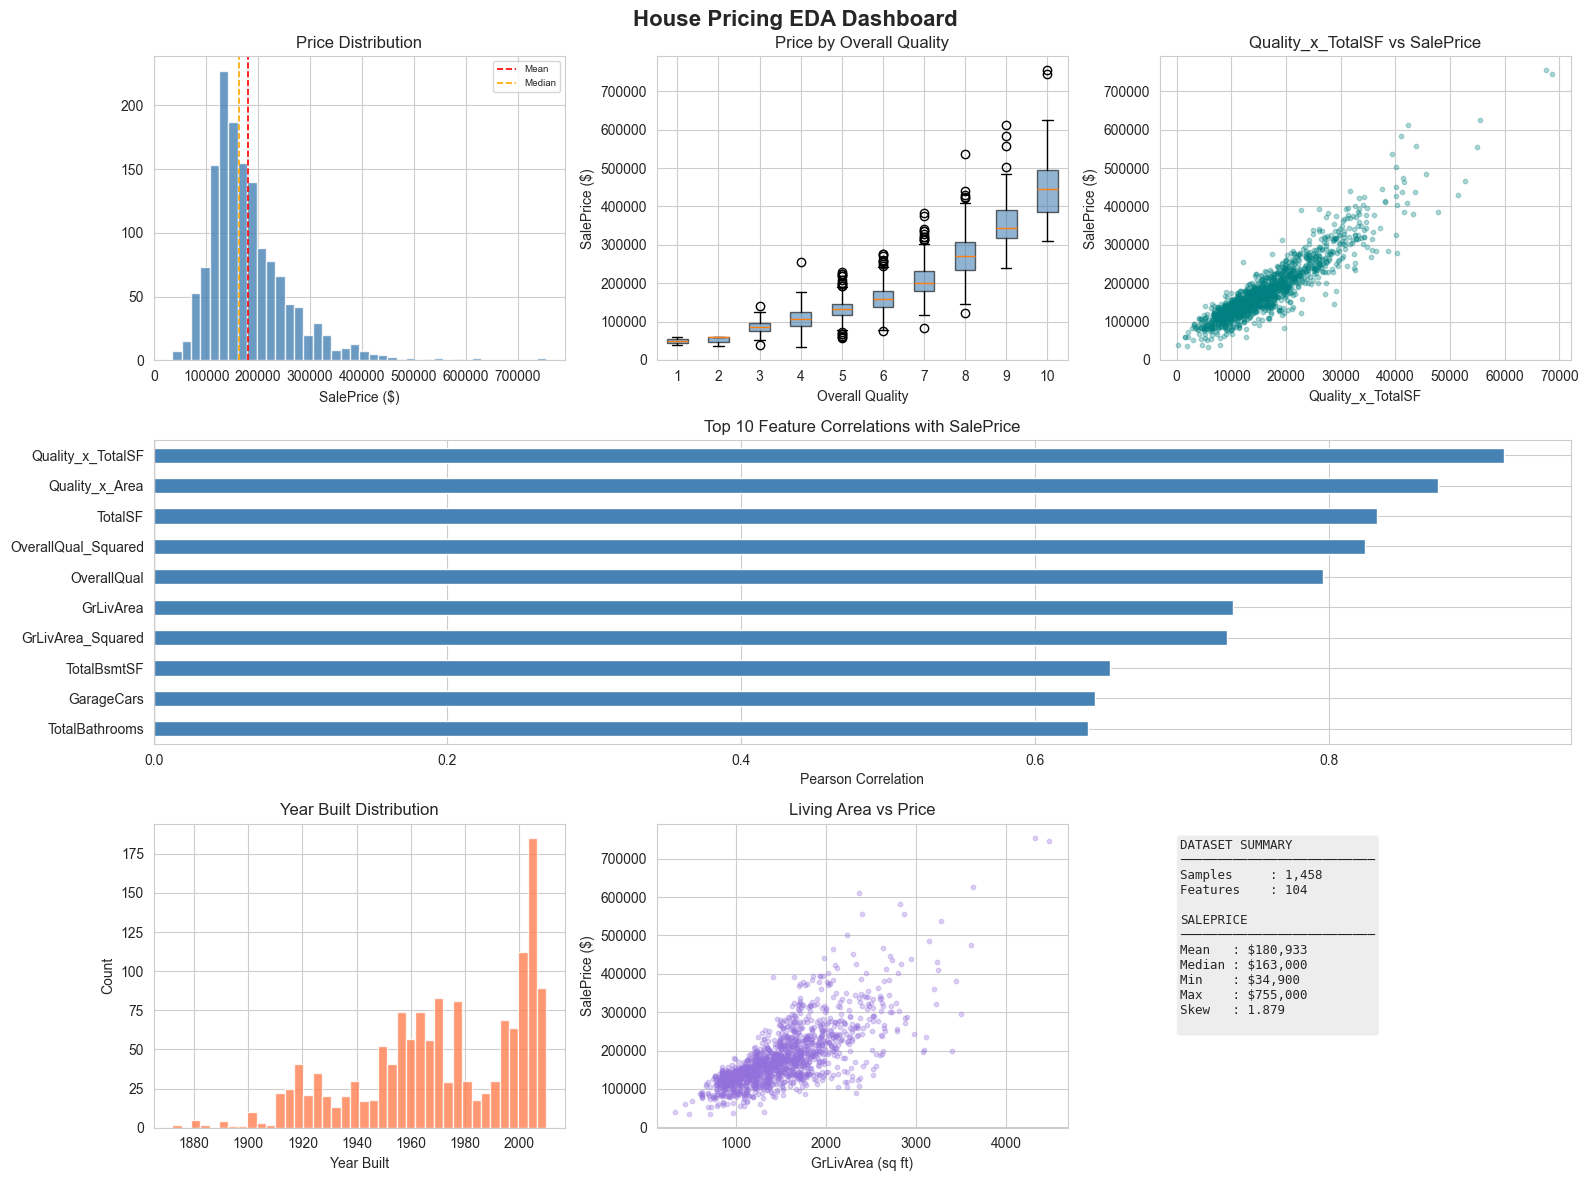

In [40]:
fig = plt.figure(figsize=(16, 12))

# --- Panel 1: Price distribution ---
ax1 = fig.add_subplot(3, 3, 1)
ax1.hist(y, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(y.mean(),   color='red',    linestyle='--', linewidth=1.2, label='Mean')
ax1.axvline(y.median(), color='orange', linestyle='--', linewidth=1.2, label='Median')
ax1.set_title('Price Distribution')
ax1.set_xlabel('SalePrice ($)')
ax1.legend(fontsize=7)

# --- Panel 2: Price by Overall Quality ---
ax2 = fig.add_subplot(3, 3, 2)
if 'OverallQual' in df_original.columns:
    qual_groups = [df_plot.loc[df_plot['OverallQual'] == q, 'SalePrice'].values
                   for q in sorted(df_plot['OverallQual'].unique())]
    ax2.boxplot(qual_groups, labels=sorted(df_plot['OverallQual'].unique()),
                patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax2.set_title('Price by Overall Quality')
    ax2.set_xlabel('Overall Quality')
    ax2.set_ylabel('SalePrice ($)')

# --- Panel 3: Top correlated feature vs price ---
ax3 = fig.add_subplot(3, 3, 3)
top_feat = correlations.drop('SalePrice').index[0]
ax3.scatter(df[top_feat], y, alpha=0.3, s=10, color='teal')
ax3.set_title(f'{top_feat} vs SalePrice')
ax3.set_xlabel(top_feat)
ax3.set_ylabel('SalePrice ($)')

# --- Panel 4: Top 10 correlations bar chart (spans full middle row) ---
ax4 = fig.add_subplot(3, 1, 2)  # full-width row
top10_corrs = correlations.drop('SalePrice').head(10).sort_values()
colors = ['steelblue' if v >= 0 else 'tomato' for v in top10_corrs]
top10_corrs.plot(kind='barh', ax=ax4, color=colors)
ax4.axvline(x=0, color='black', linewidth=0.8)
ax4.set_title('Top 10 Feature Correlations with SalePrice')
ax4.set_xlabel('Pearson Correlation')

# --- Panel 5: Year built distribution ---
ax5 = fig.add_subplot(3, 3, 7)
if 'YearBuilt' in df_original.columns:
    ax5.hist(df_original['YearBuilt'], bins=40, color='coral', edgecolor='white', alpha=0.8)
    ax5.set_title('Year Built Distribution')
    ax5.set_xlabel('Year Built')
    ax5.set_ylabel('Count')

# --- Panel 6: Living Area vs Price ---
ax6 = fig.add_subplot(3, 3, 8)
if 'GrLivArea' in df.columns:
    ax6.scatter(df['GrLivArea'], y, alpha=0.3, s=10, color='mediumpurple')
    ax6.set_title('Living Area vs Price')
    ax6.set_xlabel('GrLivArea (sq ft)')
    ax6.set_ylabel('SalePrice ($)')

# --- Panel 7: Summary statistics text box ---
ax7 = fig.add_subplot(3, 3, 9)
ax7.axis('off')
summary_text = (
    f"DATASET SUMMARY\n"
    f"{'─'*26}\n"
    f"Samples     : {len(df):,}\n"
    f"Features    : {df.shape[1]-1}\n\n"
    f"SALEPRICE\n"
    f"{'─'*26}\n"
    f"Mean   : ${y.mean():,.0f}\n"
    f"Median : ${y.median():,.0f}\n"
    f"Min    : ${y.min():,.0f}\n"
    f"Max    : ${y.max():,.0f}\n"
    f"Skew   : {stats.skew(y):.3f}\n"
)
ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.4))

plt.suptitle('House Pricing EDA Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary and Final Reflection

**What we accomplished:**
- Analyzed the target variable — confirmed right-skew, recommended log-transform for modeling
- Univariate analysis of all numerical and categorical features
- Bivariate analysis revealing strongest linear predictors of SalePrice
- Multivariate correlation heatmap and pair plots for top features
- Validated engineered features from Phase 3 — interaction features outperform raw components
- Generated a comprehensive dashboard summarizing all findings

**3 most important factors affecting house prices:**
1. **Overall Quality** — strongest single predictor; captures material and finish grade
2. **Size** (`TotalSF`, `GrLivArea`, `Quality_x_Area`) — larger, high-quality homes command strong premiums
3. **Age / Recency** (`HouseAge`, `YearBuilt`, `IsNewHouse`) — newer homes are systematically more expensive

**Modeling recommendations:**
- Use **log(SalePrice)** as target
- Apply **log/sqrt transforms** to right-skewed predictors
- Use **regularized regression** (Ridge/Lasso) or **gradient boosting** (XGBoost/LightGBM)
- Keep engineered interaction features — they show strong correlation and capture domain knowledge

---
**Congratulations!** You have completed a full data preparation pipeline: Cleaning → Preprocessing → Feature Engineering → EDA. The data is ready for machine learning modeling.